# CLIP zero-shot Evaluation
This short notebook implements the dataset split into base and novel categories (see project assignment) and runs the zero-shot evaluation with CLIP.
Feel free to copy the code contained in this notebook or to directly use this notebook as starting point for you project.

In [42]:
# we need to install clip as it is not pre-installed
# you are also free to use open_clip which provide more models
# https://github.com/mlfoundations/open_clip
%pip install openai_clip


[notice] A new release of pip is available: 24.0 -> 25.2
[notice] To update, run: pip install --upgrade pip

[notice] A new release of pip is available: 24.0 -> 25.2
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


In [ ]:
import torch
import torchvision
import torch.nn as nn
import clip
from tqdm import tqdm
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
import numpy as np

## Dataset Loading
Let's get the data directly from torchvision as we have seen during labs.

In [44]:
def get_data(data_dir="./data", transform=None):
    """Load Flowers102 train, validation and test sets.
    Args:
        data_dir (str): Directory where the dataset will be stored.
        transform (torch.Compose)
    Returns:
        tuple: A tuple containing the train, validation, and test sets.
    """
    train = torchvision.datasets.Flowers102(root=data_dir, split="train", download=True, transform=transform)
    val = torchvision.datasets.Flowers102(root=data_dir, split="val", download=True, transform=transform)
    test = torchvision.datasets.Flowers102(root=data_dir, split="test", download=True, transform=transform)
    return train, val, test

## Base and Novel categories
To split in base and novel categories we list all dataset classes, and count their number (we already know it's 102 but let's do it properly).
Then, we just allocate the first half to base categories and the remaining half to novel ones.
We can do this because we are simulating a real world application, but keep in mind this will not happen out there!

In [45]:
def base_novel_categories(dataset):
    # set returns the unique set of all dataset classes
    all_classes = set(dataset._labels)
    # and let's count them
    num_classes = len(all_classes)

    # here list(range(num_classes)) returns a list from 0 to num_classes - 1
    # then we slice the list in half and generate base and novel category lists
    base_classes = list(range(num_classes))[:num_classes//2]
    novel_classes = list(range(num_classes))[num_classes//2:]
    return base_classes, novel_classes

## Inspect Classes
Let's now visualize which are the base and novel classes.
To do so, we first get a dummy test set (without augmentations) as we are just interested in the dataset labels. Then, we split it useing `base_novel_categories`.
Finally, we use the hard-coded CLASS_NAMES to print the class in natural language.

> Note: the list of class names was only recently added to `torchvision.datasets.Flowers102`. To avoid useless errors that can occour to you, we decided to also provide such a list.

In [46]:
_, _, tmp_test = get_data()
base_classes, novel_classes = base_novel_categories(tmp_test)
CLASS_NAMES = [['pink primrose', 'pink evening primrose'], ['hard-leaved pocket orchid', 'silver slipper orchid'],
               ['canterbury bells', 'campanula medium'], ['sweet pea', 'lathyrus odoratus'], ['english marigold', 'calendula'],
               ['tiger lily'], ['moon orchid'], ['bird of paradise'], ['monkshood'], ['globe thistle'], ['snapdragon'],
               ["colt's foot", 'coltsfoot'], ['king protea'], ['spear thistle'], ['yellow iris'], ['globe-flower', 'trollius'],
               ['purple coneflower'], ['peruvian lily'], ['balloon flower', 'chinese bellflower'], ['giant white arum lily'],
               ['fire lily'], ['pincushion flower'], ['fritillary'], ['red ginger'], ['grape hyacinth'], ['corn poppy'],
               ['prince of wales feathers', 'amaranthus hypochondriacus'], ['stemless gentian'], ['artichoke', 'globe artichoke'],
               ['sweet william'], ['carnation'], ['garden phlox'], ['love in the mist', 'love-in-a-mist'],
               ['mexican aster', 'garden cosmos'], ['alpine sea holly'], ['ruby-lipped cattleya'],
               ['cape flower', 'japanese spider lily'], ['great masterwort', 'astrantia major'],
               ['siam tulip', 'curcuma alismatifolia'], ['lenten rose'], ['barbeton daisy', 'gerbera jamesonii'], ['daffodil'],
               ['sword lily', 'marsh gladiolus'], ['poinsettia'], ['bolero deep blue', 'eustoma exaltatum'],
               ['wallflower', 'erysimum'], ['marigold'], ['buttercup'], ['oxeye daisy'], ['common dandelion'], ['petunia'],
               ['wild pansy'], ['primula'], ['sunflower'], ['lilac hibiscus'], ['bishop of llandaff', 'dahlia bishop of llandaff'],
               ['gaura'], ['geranium'], ['orange dahlia'], ['pink-yellow dahlia', 'pink and yellow dahlia'], ['cautleya spicata'],
               ['japanese anemone'], ['black-eyed susan'], ['silverbush', 'shrubby bindweed'], ['californian poppy'],
               ['osteospermum'], ['spring crocus'], ['bearded iris'], ['windflower', 'wood anemone'], ['tree poppy'], ['gazania'],
               ['azalea'], ['water lily'], ['rose'], ['thorn apple', 'jimsonweed'], ['morning glory', 'morning-glory'],
               ['passion flower'], ['lotus'], ['toad lily'], ['anthurium'], ['frangipani'], ['clematis'], ['hibiscus'],
               ['columbine'], ['desert-rose'], ['tree mallow'], ['magnolia'], ['cyclamen'], ['watercress', 'nasturtium'],
               ['canna lily'], ['hippeastrum'], ['bee balm'], ['ball moss', 'tillandsia cyanea'], ['foxglove'], ['bougainvillea'],
               ['camellia'], ['mallow', 'abutilon'], ['mexican petunia', 'ruellia'], ['bromelia'], ['blanket flower'],
               ['trumpet creeper', 'campsis radicans'], ['blackberry lily']]
print("Base Class Names:", [(i, CLASS_NAMES[i]) for i in base_classes])
print("Novel Class Names:", [(i, CLASS_NAMES[i]) for i in novel_classes])

Base Class Names: [(0, ['pink primrose', 'pink evening primrose']), (1, ['hard-leaved pocket orchid', 'silver slipper orchid']), (2, ['canterbury bells', 'campanula medium']), (3, ['sweet pea', 'lathyrus odoratus']), (4, ['english marigold', 'calendula']), (5, ['tiger lily']), (6, ['moon orchid']), (7, ['bird of paradise']), (8, ['monkshood']), (9, ['globe thistle']), (10, ['snapdragon']), (11, ["colt's foot", 'coltsfoot']), (12, ['king protea']), (13, ['spear thistle']), (14, ['yellow iris']), (15, ['globe-flower', 'trollius']), (16, ['purple coneflower']), (17, ['peruvian lily']), (18, ['balloon flower', 'chinese bellflower']), (19, ['giant white arum lily']), (20, ['fire lily']), (21, ['pincushion flower']), (22, ['fritillary']), (23, ['red ginger']), (24, ['grape hyacinth']), (25, ['corn poppy']), (26, ['prince of wales feathers', 'amaranthus hypochondriacus']), (27, ['stemless gentian']), (28, ['artichoke', 'globe artichoke']), (29, ['sweet william']), (30, ['carnation']), (31, ['

## Split Dataset
The next step is to actually split the dataset into the base and novel categories we extract from `base_novel_categories`.
To split the data we need the dataset (obviously) and the list of base classes. If the sample label is not part of the base categories, then it must be part of the novel ones.

In [47]:
def split_data(dataset, base_classes):
    # these two lists will store the sample indexes
    base_categories_samples = []
    novel_categories_samples = []

    # we create a set of base classes to compute the test below in O(1)
    # this is optional and can be removed
    base_set = set(base_classes)

    # here we iterate over sample labels and also get the correspondent sample index
    for sample_id, label in enumerate(dataset._labels):
        if label in base_set:
            base_categories_samples.append(sample_id)
        else:
            novel_categories_samples.append(sample_id)

    # here we create the dataset subsets
    # the torch Subset is just a wrapper around the dataset
    # it simply stores the subset indexes and the original dataset (your_subset.dataset)
    # when asking for sample i in the subset, torch will look for its original position in the dataset and retrieve it
    # https://pytorch.org/docs/stable/data.html#torch.utils.data.Subset
    base_dataset = torch.utils.data.Subset(dataset, base_categories_samples)
    novel_dataset = torch.utils.data.Subset(dataset, novel_categories_samples)
    return base_dataset, novel_dataset

## Extract k shots
As the dataset already provides 10 train and validation shots, we do not need to extract them.
Beaware that Few-Shot Adaptation papers must do this operation as most datasets count significantly more samples in both the training and validation sets.

## Load CLIP

In [48]:
device = "cuda"
# available models = ['RN50', 'RN101', 'RN50x4', 'RN50x16', 'RN50x64', 'ViT-B/32', 'ViT-B/16', 'ViT-L/14', 'ViT-L/14@336px']
model, preprocess = clip.load("ViT-B/16", device=device)

# preprocess contains CLIP's pre-defined augmentations, let's inspect them!
preprocess

Compose(
    Resize(size=224, interpolation=bicubic, max_size=None, antialias=True)
    CenterCrop(size=(224, 224))
    <function _convert_image_to_rgb at 0x70c1f6d3d6c0>
    ToTensor()
    Normalize(mean=(0.48145466, 0.4578275, 0.40821073), std=(0.26862954, 0.26130258, 0.27577711))
)

## Load and Prepare Data
Here we get the three dataset split and pass clip pre-defined augmentations.
Then, we compute base and novel categories (in this case is redundand as we already did it before).
Finally, se split the three datasets into base and novel categories.
As we want to use the novel categories only for the test set, we drop `train_novel` and `val_novel`.

In [49]:
# get the three datasets
train_set, val_set, test_set = get_data(transform=preprocess)

# split classes into base and novel
base_classes, novel_classes = base_novel_categories(train_set)

# split the three datasets
train_base, _ = split_data(train_set, base_classes)
val_base, _ = split_data(val_set, base_classes)
test_base, test_novel = split_data(test_set, base_classes)

## Compute Zero-Shot Predictions

In [50]:
@torch.no_grad() # we don't want gradients
def eval(model: nn.Module,
         dataset: torch.utils.data.Dataset,
         categories: list[int],
         batch_size: int,
         device: str,
         label=""):
    model.eval()

    # Remap labels into a contiguous set starting from zero
    true_label_to_index = {cat: idx for idx, cat in enumerate(categories)}
    log = pd.DataFrame(columns=["true_label", "predicted_label", "correct"])
    prompts = []
    map_alias_index_to_index_label = []
    map_alias_index_to_alias_label = []
    for c in categories:
        for alias in CLASS_NAMES[c]:
            prompts.append(f"a photo of a {alias}, a type of flower.")
            map_alias_index_to_index_label.append(true_label_to_index[c])
            map_alias_index_to_alias_label.append(alias)
    text_inputs = clip.tokenize(prompts).to(device)
    text_features = model.encode_text(text_inputs)
    text_features /= text_features.norm(dim=-1, keepdim=True)

    dataloader = torch.utils.data.DataLoader(dataset, batch_size=batch_size, shuffle=False, num_workers=2)

    correct_predictions = 0
    for image, target in tqdm(dataloader, desc=label):
        true_labels = [t.item() for t in target]
        target = torch.Tensor([true_label_to_index[t.item()] for t in target]).long()

        image = image.to(device)
        target = target.to(device)

        image_features = model.encode_image(image)
        image_features /= image_features.norm(dim=-1, keepdim=True)
        
        predicted_class = (image_features @ text_features.T).argmax(dim=-1)
        predicted_labels = [map_alias_index_to_alias_label[p.item()] for p in predicted_class]
        predicted_class = torch.Tensor([map_alias_index_to_index_label[p.item()] for p in predicted_class]).long().to(device)
        prediction_correctness = (predicted_class == target).tolist()
        batch_data = []
        for i, correct in enumerate(prediction_correctness):
            batch_data.append({"true_label": true_labels[i],
                              "predicted_label": predicted_labels[i],
                              "correct": correct})
        
        batch_df = pd.DataFrame(batch_data)
        log = pd.concat([log, batch_df], ignore_index=True)
        correct_predictions += sum(prediction_correctness)
    accuracy = correct_predictions / len(dataset)
    return accuracy, log

base_accuracy, base_log = eval(model=model, dataset=test_base, categories=base_classes, batch_size=128, device=device, label="🧠 Zero-shot evaluation on Base Classes")
novel_accuracy, novel_log = eval(model=model, dataset=test_novel, categories=novel_classes, batch_size=128, device=device, label="🧠 Zero-shot evaluation on Novel Classes")
print()
print(f"🔍 Base classes accuracy: {base_accuracy*100:.2f}%")
print(f"🔍 Novel classes accuracy: {novel_accuracy*100:.2f}%")


🧠 Zero-shot evaluation on Base Classes: 100%|██████████| 20/20 [01:32<00:00,  4.63s/it]

🧠 Zero-shot evaluation on Novel Classes: 100%|██████████| 29/29 [02:15<00:00,  4.68s/it]


🔍 Base classes accuracy: 85.60%
🔍 Novel classes accuracy: 91.62%


## Harmonic Mean
Few-Shot Adaptations papers usually report the Harmonic Mean.
The harmonic mean tends to mitigate the impact of large outliers (base accuracy) and aggravate the impact of small ones (novel accuracy).
Thus, achieving very high base accuracies at the expense of the novel accuracy will be penalized by the HM.

In [51]:
def harmonic_mean(base_accuracy, novel_accuracy):
    numerator = 2
    denominator = 1 / base_accuracy + 1 / novel_accuracy
    hm = numerator / denominator
    return hm

print(f"🔍 Harmonic Mean: {harmonic_mean(base_accuracy, novel_accuracy)*100:.2f}%")

🔍 Harmonic Mean: 88.51%


In [52]:
map_alias_to_label_index = {}
for index in range(len(CLASS_NAMES)):
    for alias in CLASS_NAMES[index]:
        map_alias_to_label_index[alias] = index
base_classes_sample_counts = base_log['true_label'].value_counts().sort_index()
novel_classes_sample_counts = novel_log['true_label'].value_counts().sort_index()

# Concatenate base and novel counts
all_classes_sample_counts = pd.concat([base_classes_sample_counts, novel_classes_sample_counts]).sort_index()

# Merge base and novel logs
combined_log = pd.concat([base_log, novel_log], ignore_index=True)

# Compute correct predictions for each alias
alias_correct_predictions = combined_log[combined_log['correct'] == True]['predicted_label'].value_counts()

# Create metrics dictionary for each alias
alias_metrics = {}
for alias in map_alias_to_label_index.keys():
    class_index = map_alias_to_label_index[alias]
    
    # Get correct predictions for this alias
    correct_preds = alias_correct_predictions.get(alias, 0)
    
    # Get total samples for this class
    total_samples = all_classes_sample_counts.get(class_index, 0)
    
    # Get total predictions for this alias (correct + incorrect)
    total_predictions = combined_log[combined_log['predicted_label'] == alias].shape[0]
    
    # Calculate precision (correct predictions / total predictions for this alias)
    precision = correct_preds / total_predictions if total_predictions > 0 else 0.0
    recall = correct_preds / total_samples if total_samples > 0 else 0.0
    
    alias_metrics[alias] = {
        'correct_predictions': correct_preds,
        'total_class_samples': total_samples,
        'total_predictions': total_predictions,
        'precision': precision,
        'recall': recall
    }
alias_metrics_df = pd.DataFrame.from_dict(alias_metrics, orient='index')
with pd.option_context('display.max_rows', None, 'display.max_columns', None):
    display(alias_metrics_df)

,correct_predictions,total_class_samples,total_predictions,precision,recall
pink primrose,3,20,7,0.428571,0.150000
pink evening primrose,16,20,21,0.761905,0.800000
hard-leaved pocket orchid,0,40,3,0.000000,0.000000
silver slipper orchid,28,40,37,0.756757,0.700000
canterbury bells,0,20,11,0.000000,0.000000
campanula medium,10,20,20,0.500000,0.500000
sweet pea,5,36,5,1.000000,0.138889
lathyrus odoratus,25,36,31,0.806452,0.694444
english marigold,3,45,18,0.166667,0.066667
calendula,39,45,46,0.847826,0.866667


In [53]:
# Count correct predictions for each class
base_correct_predictions_counts = base_log[base_log['correct'] == True]['true_label'].value_counts().sort_index()
novel_correct_predictions_counts = novel_log[novel_log['correct'] == True]['true_label'].value_counts().sort_index()

# Concatenate base and novel correct predictions
all_classes_correct_predictions_counts = pd.concat([base_correct_predictions_counts, novel_correct_predictions_counts]).sort_index()

# Calculate accuracy for each class
class_accuracies = {}
for class_id in range(len(CLASS_NAMES)):
    correct_preds = all_classes_correct_predictions_counts.get(class_id, 0)
    total_samples = all_classes_sample_counts.get(class_id, 0)
    recall = correct_preds / total_samples if total_samples > 0 else 0.0
    
    class_accuracies[class_id] = {
        'class_name': CLASS_NAMES[class_id][0],  # Primary name for the class
        'all_aliases': CLASS_NAMES[class_id],    # All aliases for this class
        'correct_predictions': correct_preds,
        'total_samples': total_samples,
        'recall': recall,
    }

# Convert to DataFrame
class_accuracies_df = pd.DataFrame.from_dict(class_accuracies, orient='index')
with pd.option_context('display.max_rows', None, 'display.max_columns', None):
    display(class_accuracies_df)

,class_name,all_aliases,correct_predictions,total_samples,recall
0,pink primrose,"[pink primrose, pink evening primrose]",19,20,0.950000
1,hard-leaved pocket orchid,"[hard-leaved pocket orchid, silver slipper orc...",28,40,0.700000
2,canterbury bells,"[canterbury bells, campanula medium]",10,20,0.500000
3,sweet pea,"[sweet pea, lathyrus odoratus]",30,36,0.833333
4,english marigold,"[english marigold, calendula]",42,45,0.933333
5,tiger lily,[tiger lily],17,25,0.680000
6,moon orchid,[moon orchid],16,20,0.800000
7,bird of paradise,[bird of paradise],65,65,1.000000
8,monkshood,[monkshood],25,26,0.961538
9,globe thistle,[globe thistle],22,25,0.880000


In [58]:
for key in map_alias_to_label_index:
    if key is None or map_alias_to_label_index[key] is None:
        print(f"Problematic key: {key}, value: {map_alias_to_label_index[key]}")
print(base_log['predicted_label'].head(10))
print(map_alias_to_label_index['pink primrose'])

0    pink evening primrose
1    pink evening primrose
2    pink evening primrose
3            pink primrose
4    pink evening primrose
5    pink evening primrose
6    pink evening primrose
7            pink primrose
8    pink evening primrose
9    pink evening primrose
Name: predicted_label, dtype: object
0


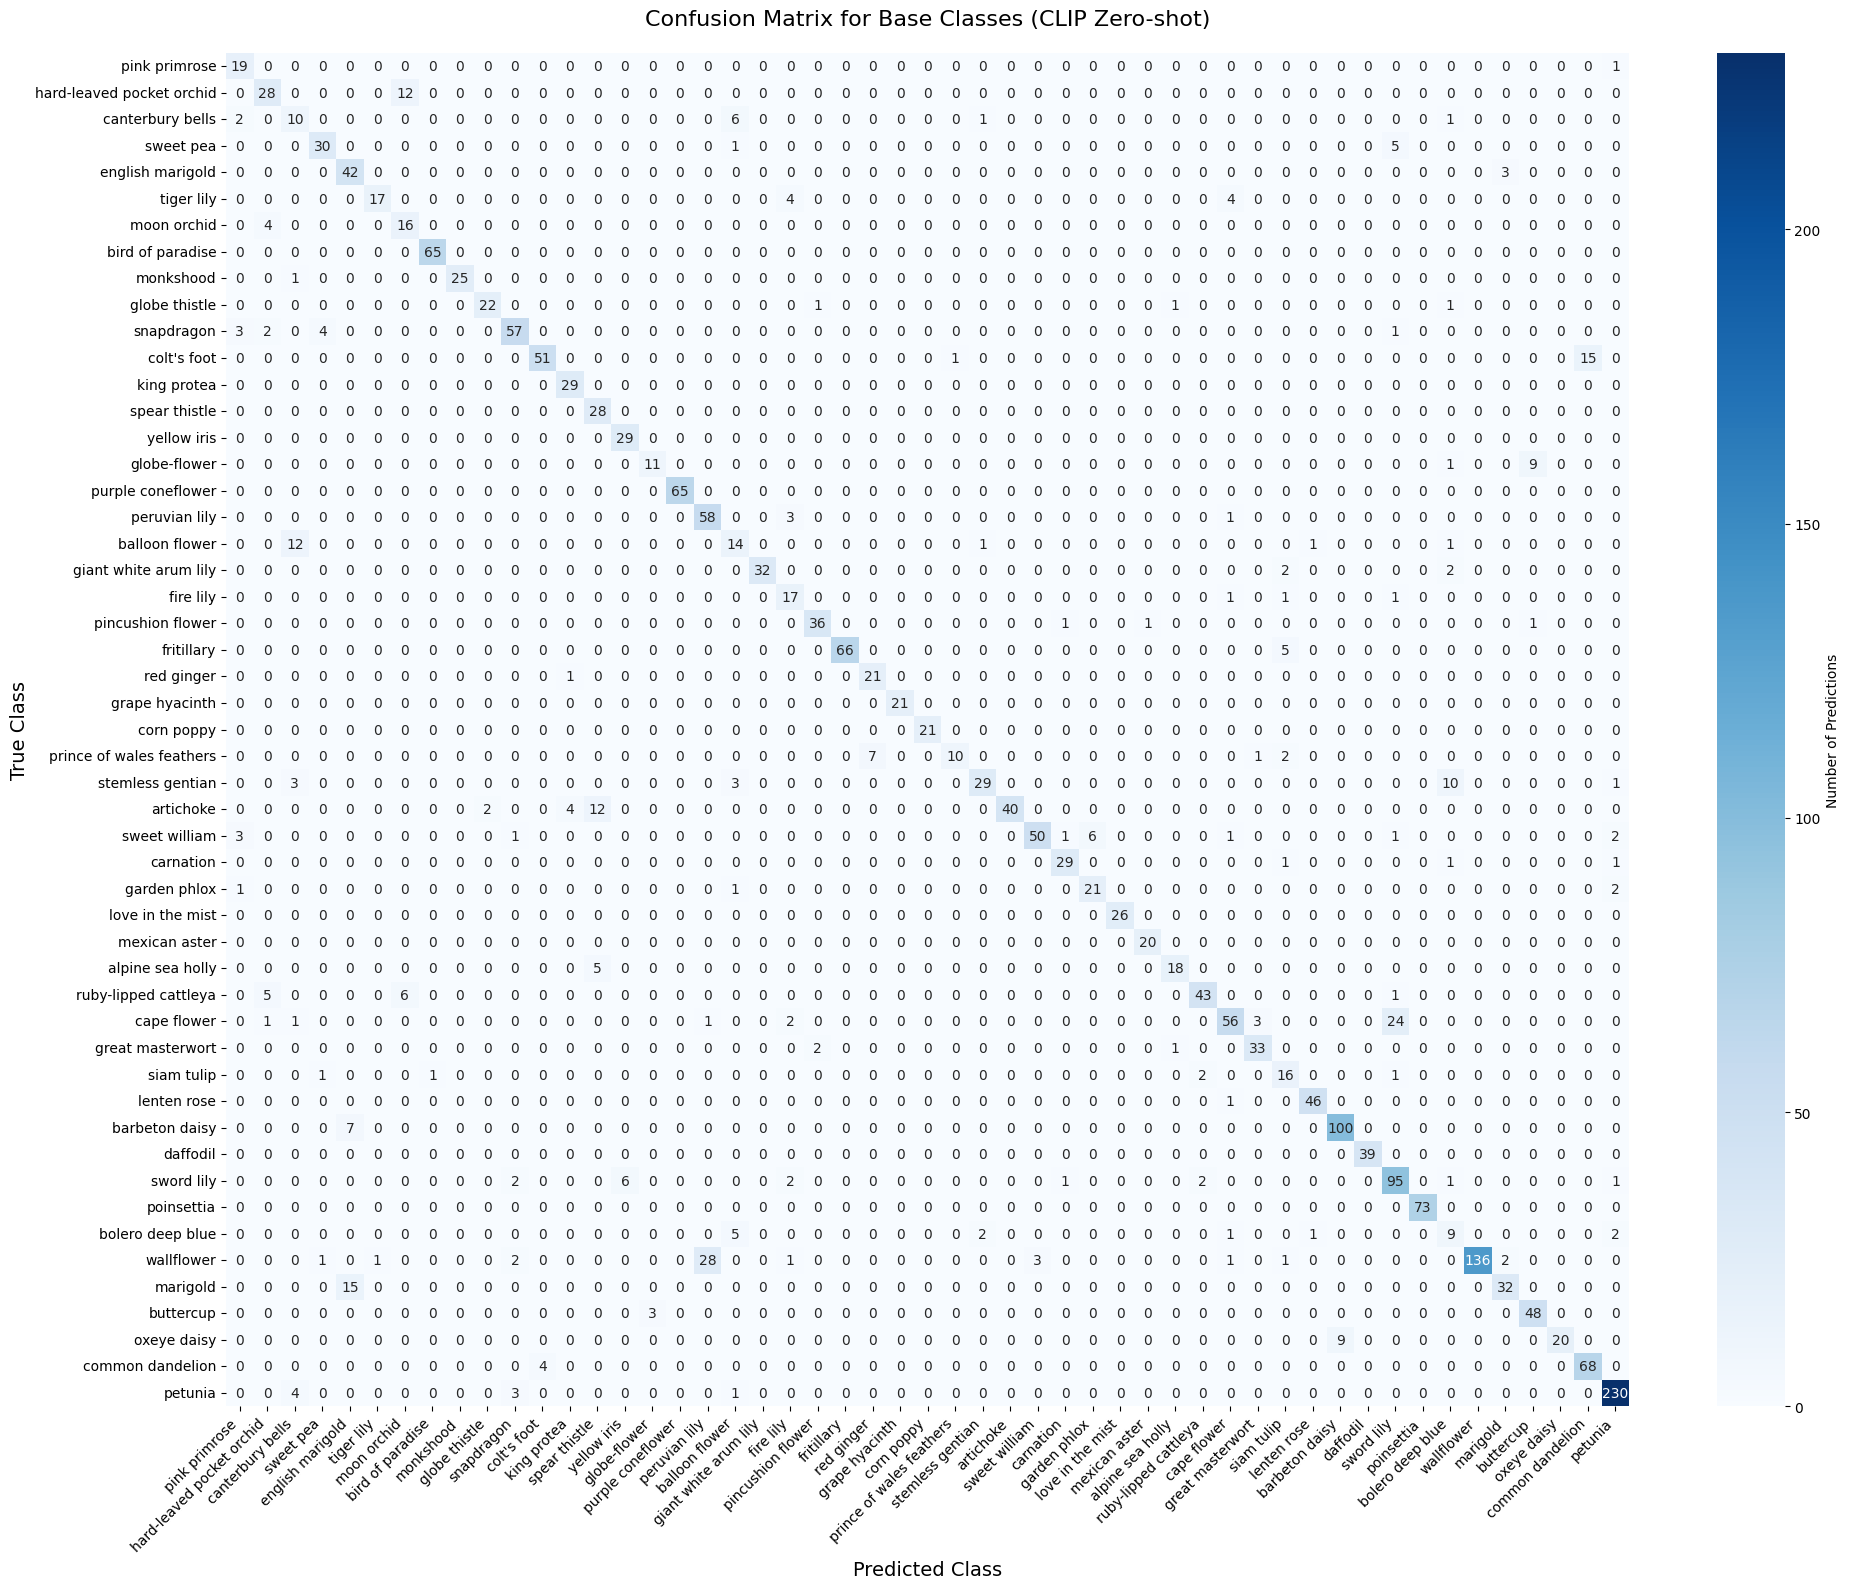

📊 Confusion Matrix Statistics:
Matrix shape: (51, 51)
Total predictions: 2473
Correct predictions (diagonal): 2117
Accuracy: 0.8560

🔀 Most confused pair:
True class: wallflower (class 45)
Predicted as: peruvian lily (class 17)
Confusion count: 28


In [ ]:
# Convert predicted aliases to class indices for base_log
base_log_with_pred_indices = base_log.copy()
base_log_with_pred_indices['predicted_label'] = base_log_with_pred_indices['predicted_label'].map(map_alias_to_label_index)
base_log_with_pred_indices['true_label'] = base_log_with_pred_indices['true_label'].astype(int)
base_log_with_pred_indices['predicted_label'] = base_log_with_pred_indices['predicted_label'].astype(int)

# Get true and predicted class indices
y_true = base_log_with_pred_indices['true_label'].values
y_pred = base_log_with_pred_indices['predicted_label'].values

# Create confusion matrix
cm = confusion_matrix(y_true, y_pred, labels=base_classes)

# Create a more readable confusion matrix with class names
base_class_names = [CLASS_NAMES[i][0] for i in base_classes]  # Use primary name for each class

# Plot confusion matrix
plt.figure(figsize=(20, 16))
sns.heatmap(cm, 
            xticklabels=base_class_names, 
            yticklabels=base_class_names,
            annot=True, 
            fmt='d', 
            cmap='Blues',
            cbar_kws={'label': 'Number of Predictions'})

plt.title('Confusion Matrix for Base Classes (CLIP Zero-shot)', fontsize=16, pad=20)
plt.xlabel('Predicted Class', fontsize=14)
plt.ylabel('True Class', fontsize=14)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

# Print some statistics about the confusion matrix
print(f"📊 Confusion Matrix Statistics:")
print(f"Matrix shape: {cm.shape}")
print(f"Total predictions: {cm.sum()}")
print(f"Correct predictions (diagonal): {np.trace(cm)}")
print(f"Accuracy: {np.trace(cm) / cm.sum():.4f}")

# Find most confused classes (highest off-diagonal values)
cm_off_diagonal = cm.copy()
np.fill_diagonal(cm_off_diagonal, 0)
max_confusion_idx = np.unravel_index(np.argmax(cm_off_diagonal), cm_off_diagonal.shape)
max_confusion_count = cm_off_diagonal[max_confusion_idx]

true_class_idx = base_classes[max_confusion_idx[0]]
pred_class_idx = base_classes[max_confusion_idx[1]]

print(f"\n🔀 Most confused pair:")
print(f"True class: {CLASS_NAMES[true_class_idx][0]} (class {true_class_idx})")
print(f"Predicted as: {CLASS_NAMES[pred_class_idx][0]} (class {pred_class_idx})")
print(f"Confusion count: {max_confusion_count}")

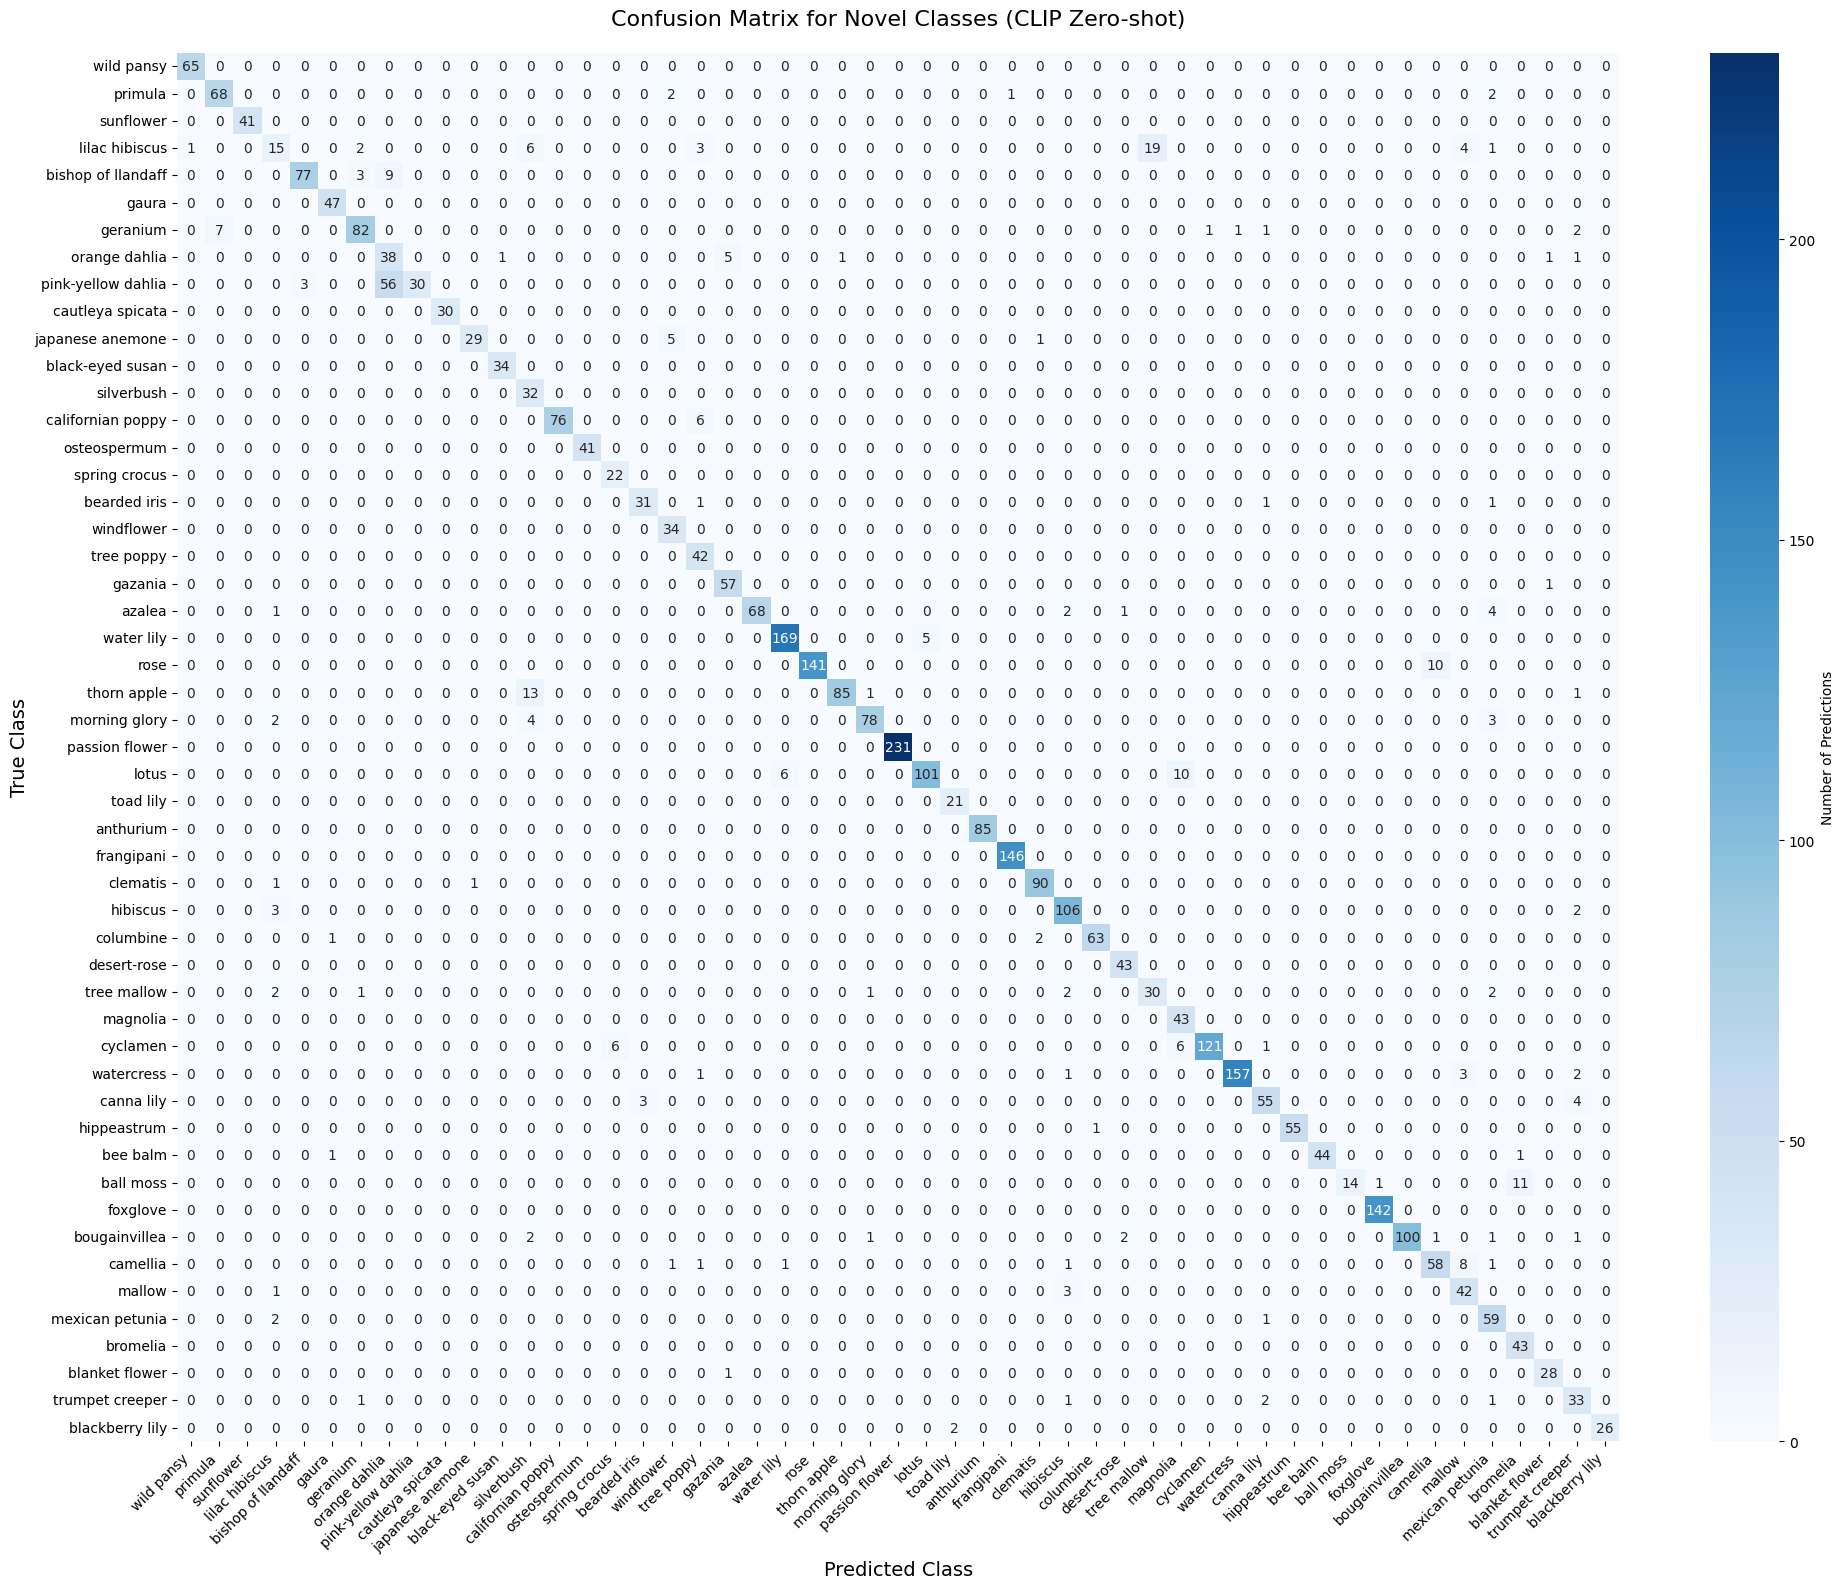

📊 Confusion Matrix Statistics:
Matrix shape: (51, 51)
Total predictions: 3676
Correct predictions (diagonal): 3368
Accuracy: 0.9162

🔀 Most confused pair:
True class: pink-yellow dahlia (class 59)
Predicted as: orange dahlia (class 58)
Confusion count: 56


In [63]:
# Convert predicted aliases to class indices for novel_log
novel_log_with_pred_indices = novel_log.copy()
novel_log_with_pred_indices['predicted_label'] = novel_log_with_pred_indices['predicted_label'].map(map_alias_to_label_index)
novel_log_with_pred_indices['true_label'] = novel_log_with_pred_indices['true_label'].astype(int)
novel_log_with_pred_indices['predicted_label'] = novel_log_with_pred_indices['predicted_label'].astype(int)

# Get true and predicted class indices
y_true = novel_log_with_pred_indices['true_label'].values
y_pred = novel_log_with_pred_indices['predicted_label'].values

# Create confusion matrix
cm = confusion_matrix(y_true, y_pred, labels=novel_classes)

# Create a more readable confusion matrix with class names
novel_class_names = [CLASS_NAMES[i][0] for i in novel_classes]  # Use primary name for each class

# Plot confusion matrix
plt.figure(figsize=(20, 16))
sns.heatmap(cm, 
            xticklabels=novel_class_names, 
            yticklabels=novel_class_names,
            annot=True, 
            fmt='d', 
            cmap='Blues',
            cbar_kws={'label': 'Number of Predictions'})

plt.title('Confusion Matrix for Novel Classes (CLIP Zero-shot)', fontsize=16, pad=20)
plt.xlabel('Predicted Class', fontsize=14)
plt.ylabel('True Class', fontsize=14)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

# Print some statistics about the confusion matrix
print(f"📊 Confusion Matrix Statistics:")
print(f"Matrix shape: {cm.shape}")
print(f"Total predictions: {cm.sum()}")
print(f"Correct predictions (diagonal): {np.trace(cm)}")
print(f"Accuracy: {np.trace(cm) / cm.sum():.4f}")

# Find most confused classes (highest off-diagonal values)
cm_off_diagonal = cm.copy()
np.fill_diagonal(cm_off_diagonal, 0)
max_confusion_idx = np.unravel_index(np.argmax(cm_off_diagonal), cm_off_diagonal.shape)
max_confusion_count = cm_off_diagonal[max_confusion_idx]

true_class_idx = novel_classes[max_confusion_idx[0]]
pred_class_idx = novel_classes[max_confusion_idx[1]]

print(f"\n🔀 Most confused pair:")
print(f"True class: {CLASS_NAMES[true_class_idx][0]} (class {true_class_idx})")
print(f"Predicted as: {CLASS_NAMES[pred_class_idx][0]} (class {pred_class_idx})")
print(f"Confusion count: {max_confusion_count}")

In [ ]:
# Summary statistics
total_aliases = len(alias_metrics)
aliases_with_predictions = sum(1 for metrics in alias_metrics.values() if metrics['total_predictions'] > 0)
avg_precision = sum(metrics['precision'] for metrics in alias_metrics.values()) / total_aliases

print(f"📊 Summary Statistics:")
print(f"Total aliases: {total_aliases}")
print(f"Aliases with at least one prediction: {aliases_with_predictions}")
print(f"Average precision across all aliases: {avg_precision:.4f}")

# Find best and worst performing aliases
best_alias = max(alias_metrics.items(), key=lambda x: x[1]['precision'])
worst_alias = min(alias_metrics.items(), key=lambda x: x[1]['precision'] if x[1]['total_predictions'] > 0 else float('inf'))

print(f"\n🏆 Best performing alias: {best_alias[0]} (precision: {best_alias[1]['precision']:.4f})")
print(f"🚫 Worst performing alias (with predictions): {worst_alias[0]} (precision: {worst_alias[1]['precision']:.4f})")

# Show aliases that were never predicted
never_predicted = [alias for alias, metrics in alias_metrics.items() if metrics['total_predictions'] == 0]
print(f"\n❌ Aliases never predicted: {len(never_predicted)} out of {total_aliases}")
if len(never_predicted) <= 10:
    print(f"Never predicted aliases: {never_predicted}")
else:
    print(f"First 10 never predicted aliases: {never_predicted[:10]}")

# Convert to DataFrame for easier analysis if needed
import pandas as pd
alias_metrics_df = pd.DataFrame.from_dict(alias_metrics, orient='index')
print(f"\n📈 Top 10 aliases by precision:")
with pd.option_context('display.max_rows', None, 'display.max_columns', None):
    display(alias_metrics_df.sort_values('precision', ascending=False).head(10))

📊 Summary Statistics:
Total aliases: 132
Aliases with at least one prediction: 124
Average precision across all aliases: 0.7412

🏆 Best performing alias: sweet pea (precision: 1.0000)
🚫 Worst performing alias (with predictions): hard-leaved pocket orchid (precision: 0.0000)

❌ Aliases never predicted: 8 out of 132
Never predicted aliases: ["colt's foot", 'globe-flower', 'love in the mist', 'bishop of llandaff', 'silverbush', 'morning glory', 'watercress', 'ball moss']

📈 Top 10 aliases by precision:


,correct_predictions,total_class_samples,total_predictions,precision,accuracy
grape hyacinth,21,21,21,1.0,1.000000
corn poppy,21,21,21,1.0,1.000000
monkshood,25,26,25,1.0,0.961538
sweet pea,5,36,5,1.0,0.138889
passion flower,231,231,231,1.0,1.000000
anthurium,85,85,85,1.0,1.000000
bee balm,44,46,44,1.0,0.956522
blackberry lily,26,28,26,1.0,0.928571
fritillary,66,71,66,1.0,0.929577
amaranthus hypochondriacus,10,20,10,1.0,0.500000
